# 03 — Profit & Business Intelligence Analysis
## Decision Intelligence System · Olist E-Commerce Dataset

**Objective:** Deep-dive into profitability across every business dimension to answer:
- Which product categories generate the most profit?
- Which sellers are the most valuable?
- Where are the profit leaks (high freight ratio)?
- Which states are most profitable per order?
- How has profitability trended over time?
- What is the relationship between price, freight and review score?

> **Note on Profit Proxy:** Olist does not publish cost-of-goods data. We define:
> `profit_proxy = price - freight_value`
> This measures net revenue after logistics cost — a realistic margin approximation.

**Input:** `master_olist.csv` from Notebook 01  
**Output:** Charts saved to `outputs/` + profit summary tables

---

## 1. Imports & Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import warnings
import os
warnings.filterwarnings('ignore')

# Paths
DATA_PATH    = '../data/'
OUTPUTS_PATH = '../outputs/'
os.makedirs(DATA_PATH,    exist_ok=True)
os.makedirs(OUTPUTS_PATH, exist_ok=True)

# Display settings
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.2f}'.format)
plt.rcParams['figure.figsize']    = (13, 5)
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.grid']         = True
plt.rcParams['grid.alpha']        = 0.3

BLUE   = '#378ADD'
GREEN  = '#1D9E75'
AMBER  = '#EF9F27'
CORAL  = '#D85A30'
PURPLE = '#7F77DD'

print('Setup complete!')

Setup complete!


## 2. Load Master Dataset

In [2]:
master = pd.read_csv(DATA_PATH + 'master_olist.csv', low_memory=False)

date_cols = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
]
for col in date_cols:
    master[col] = pd.to_datetime(master[col], errors='coerce')

master['order_month_str'] = master['order_purchase_timestamp'].dt.strftime('%Y-%m')
master['order_year']      = master['order_purchase_timestamp'].dt.year

# Work only with delivered orders for profit analysis
delivered = master[master['order_status'] == 'delivered'].copy()

# Recalculate profit proxy cleanly
delivered['profit_proxy']  = delivered['price'] - delivered['freight_value']
delivered['freight_ratio'] = delivered['freight_value'] / delivered['price'].replace(0, np.nan)

print(f'Delivered orders loaded: {delivered.shape[0]:,} rows')
print(f'Profit proxy range: R$ {delivered["profit_proxy"].min():.2f} to R$ {delivered["profit_proxy"].max():.2f}')
delivered[['price', 'freight_value', 'profit_proxy', 'freight_ratio']].describe()

Delivered orders loaded: 110,197 rows
Profit proxy range: R$ -140.53 to R$ 6540.69


,price,freight_value,profit_proxy,freight_ratio
count,110197.00,110197.00,110197.00,110197.00
mean,119.98,19.95,100.03,0.32
std,182.30,15.70,176.40,0.35
min,0.85,0.00,-140.53,0.00
25%,39.90,13.08,24.45,0.13
50%,74.90,16.26,56.15,0.23
75%,134.17,21.15,111.56,0.39
max,6735.00,409.68,6540.69,26.24


## 3. Overall Profit KPIs

In [3]:
total_revenue      = delivered['price'].sum()
total_freight      = delivered['freight_value'].sum()
total_profit       = delivered['profit_proxy'].sum()
overall_margin_pct = (total_profit / total_revenue * 100)
avg_profit_order   = delivered.groupby('order_id')['profit_proxy'].sum().mean()
avg_freight_ratio  = (total_freight / total_revenue * 100)
negative_margin    = (delivered['profit_proxy'] < 0).sum()
negative_margin_pct= (negative_margin / len(delivered) * 100)

print('=' * 55)
print('        PROFIT INTELLIGENCE — HEADLINE KPIs')
print('=' * 55)
print(f'  Total Product Revenue  : R$ {total_revenue:>12,.2f}')
print(f'  Total Freight Cost     : R$ {total_freight:>12,.2f}')
print(f'  Total Profit Proxy     : R$ {total_profit:>12,.2f}')
print(f'  Overall Margin %       : {overall_margin_pct:>14.1f}%')
print(f'  Avg Profit per Order   : R$ {avg_profit_order:>12,.2f}')
print(f'  Freight % of Revenue   : {avg_freight_ratio:>14.1f}%')
print(f'  Negative Margin Orders : {negative_margin:>12,} ({negative_margin_pct:.1f}%)')
print('=' * 55)

        PROFIT INTELLIGENCE — HEADLINE KPIs
  Total Product Revenue  : R$ 13,221,498.11
  Total Freight Cost     : R$ 2,198,275.64
  Total Profit Proxy     : R$ 11,023,222.47
  Overall Margin %       :           83.4%
  Avg Profit per Order   : R$       114.26
  Freight % of Revenue   :           16.6%
  Negative Margin Orders :        4,008 (3.6%)


## 4. Chart 1 — Profit Proxy by Product Category (Top 20)

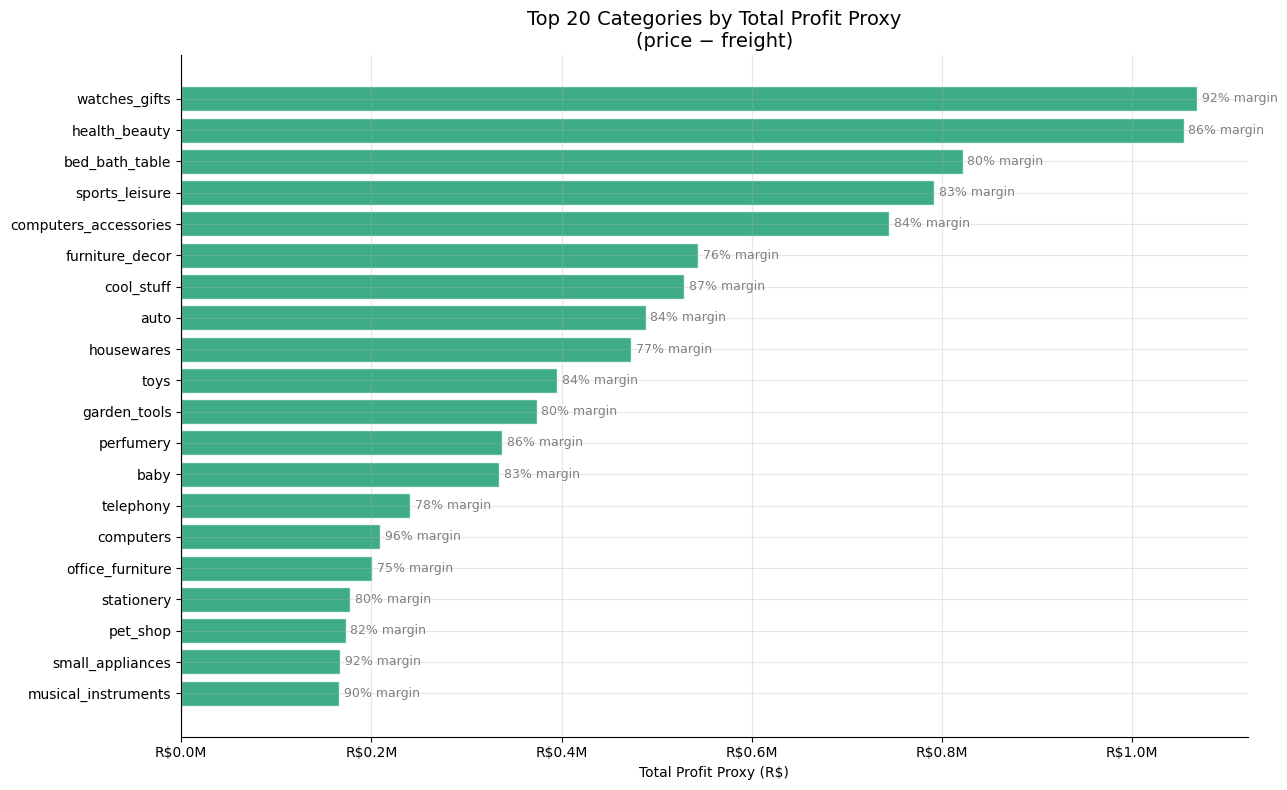

Chart saved!

Top 10 Categories by Profit:
product_category_name_english  total_revenue  total_profit  margin_pct  avg_review
                watches_gifts     1166176.98    1068020.84       91.60        4.07
                health_beauty     1233131.72    1054173.91       85.50        4.19
               bed_bath_table     1023434.76     821660.26       80.30        3.92
               sports_leisure      954852.55     791448.19       82.90        4.17
        computers_accessories      888724.61     744725.45       83.80        3.99
              furniture_decor      711927.69     543525.46       76.30        3.95
                   cool_stuff      610204.10     528727.31       86.60        4.19
                         auto      578966.65     488478.55       84.40        4.12
                   housewares      615628.69     472865.13       76.80        4.11
                         toys      471286.48     395511.90       83.90        4.21


In [4]:
category_profit = (
    delivered
    .dropna(subset=['product_category_name_english'])
    .groupby('product_category_name_english')
    .agg(
        total_revenue  = ('price',          'sum'),
        total_freight  = ('freight_value',   'sum'),
        total_profit   = ('profit_proxy',    'sum'),
        order_count    = ('order_id',        'nunique'),
        avg_price      = ('price',           'mean'),
        avg_freight    = ('freight_value',   'mean'),
        avg_review     = ('review_score',    'mean')
    )
    .reset_index()
)
category_profit['margin_pct']      = (category_profit['total_profit'] / category_profit['total_revenue'] * 100).round(1)
category_profit['freight_ratio']   = (category_profit['total_freight'] / category_profit['total_revenue'] * 100).round(1)
category_profit['profit_per_order']= (category_profit['total_profit'] / category_profit['order_count']).round(2)

top20 = category_profit.nlargest(20, 'total_profit')

fig, ax = plt.subplots(figsize=(13, 8))
colors = [GREEN if v > 0 else CORAL for v in top20['total_profit']]
bars = ax.barh(top20['product_category_name_english'],
               top20['total_profit'],
               color=colors, alpha=0.85, edgecolor='white')

for bar, margin in zip(bars, top20['margin_pct']):
    ax.text(bar.get_width() + 5000,
            bar.get_y() + bar.get_height()/2,
            f'{margin:.0f}% margin',
            va='center', fontsize=9, color='gray')

ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Top 20 Categories by Total Profit Proxy\n(price − freight)', fontsize=14)
ax.set_xlabel('Total Profit Proxy (R$)')
ax.invert_yaxis()
ax.xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'R${x/1e6:.1f}M'))

plt.tight_layout()
plt.savefig(OUTPUTS_PATH + 'profit_by_category.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved!')
print('\nTop 10 Categories by Profit:')
print(category_profit.nlargest(10, 'total_profit')[
    ['product_category_name_english','total_revenue','total_profit','margin_pct','avg_review']
].to_string(index=False))

## 5. Chart 2 — Margin % vs Order Volume (Bubble Chart)

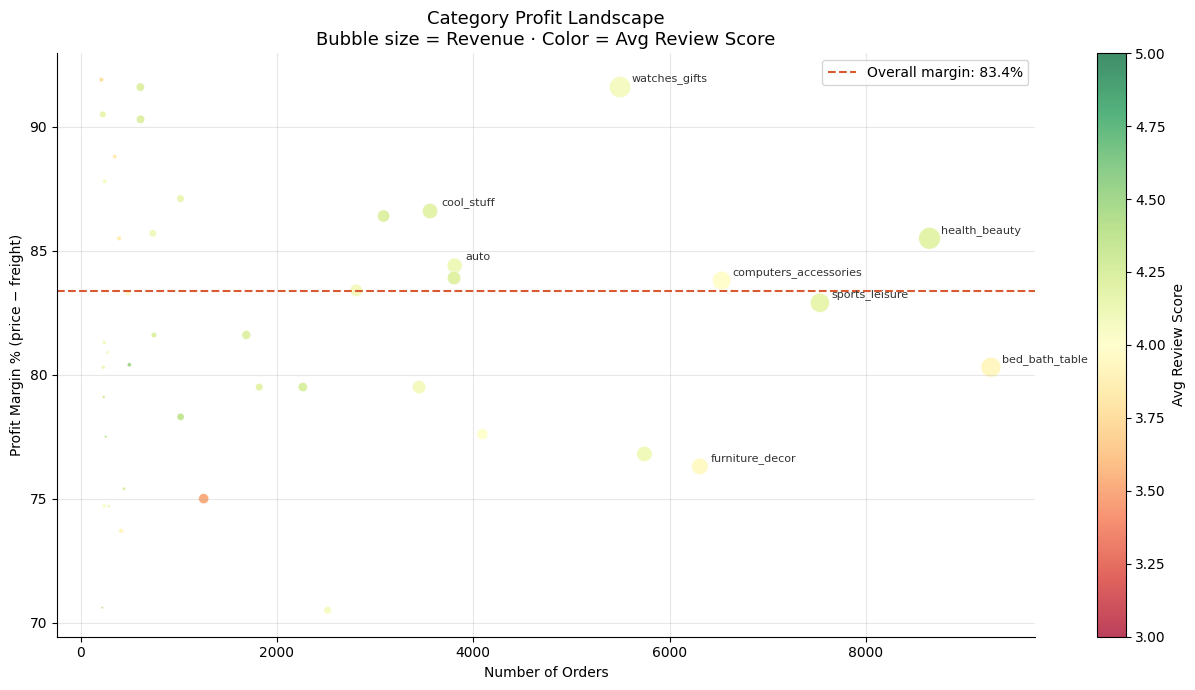

Chart saved!


In [5]:
# Filter to categories with at least 200 orders for reliability
bubble_data = category_profit[category_profit['order_count'] >= 200].copy()

fig, ax = plt.subplots(figsize=(13, 7))

scatter = ax.scatter(
    bubble_data['order_count'],
    bubble_data['margin_pct'],
    s=bubble_data['total_revenue'] / 5000,
    c=bubble_data['avg_review'],
    cmap='RdYlGn',
    alpha=0.75,
    edgecolors='white',
    linewidth=0.5,
    vmin=3.0, vmax=5.0
)

plt.colorbar(scatter, ax=ax, label='Avg Review Score')

# Label top categories
top_labels = bubble_data.nlargest(8, 'total_profit')
for _, row in top_labels.iterrows():
    ax.annotate(
        row['product_category_name_english'],
        (row['order_count'], row['margin_pct']),
        fontsize=8,
        xytext=(8, 4),
        textcoords='offset points',
        color='#333333'
    )

ax.axhline(overall_margin_pct, color=CORAL, linewidth=1.5,
           linestyle='--', label=f'Overall margin: {overall_margin_pct:.1f}%')
ax.set_title('Category Profit Landscape\nBubble size = Revenue · Color = Avg Review Score', fontsize=13)
ax.set_xlabel('Number of Orders')
ax.set_ylabel('Profit Margin % (price − freight)')
ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig(OUTPUTS_PATH + 'category_profit_bubble.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved!')

**Insight:** The ideal category sits top-right — high volume AND high margin. Categories in the bottom-left are both small and low-margin — deprioritise. Colors near red = customer dissatisfaction risk on top of low profit.

## 6. Chart 3 — Freight Cost Deep Dive

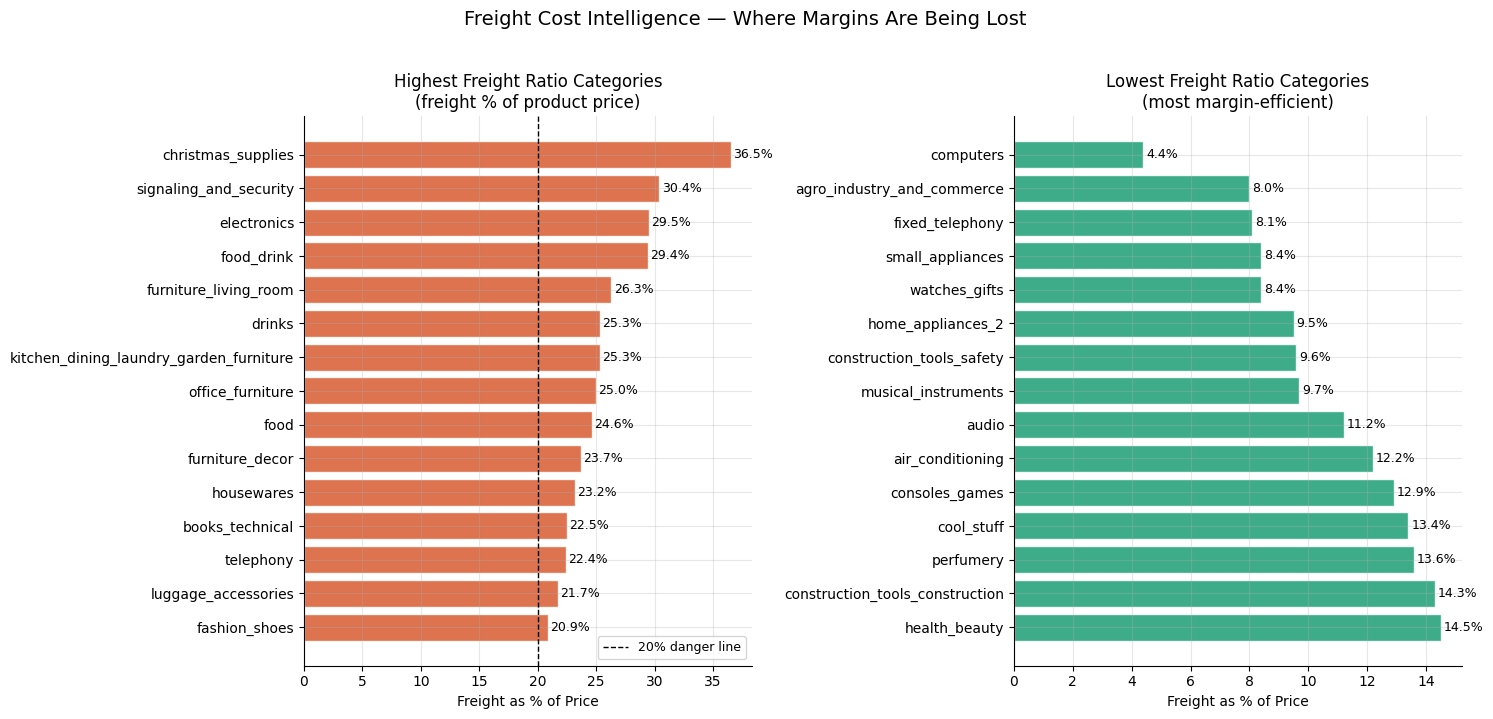

Chart saved!

Revenue in high freight (>30%) categories: R$ 38,477
If freight reduced by 10% in those categories:
  Estimated profit gain: R$ 1,154


In [6]:
# Categories where freight eats the most margin
high_freight = category_profit[category_profit['order_count'] >= 100].nlargest(15, 'freight_ratio')
low_freight  = category_profit[category_profit['order_count'] >= 100].nsmallest(15, 'freight_ratio')

fig, axes = plt.subplots(1, 2, figsize=(15, 7))

# High freight ratio — profit killers
bars_h = axes[0].barh(high_freight['product_category_name_english'],
                      high_freight['freight_ratio'],
                      color=CORAL, alpha=0.85, edgecolor='white')
for bar, val in zip(bars_h, high_freight['freight_ratio']):
    axes[0].text(bar.get_width() + 0.2, bar.get_y() + bar.get_height()/2,
                 f'{val:.1f}%', va='center', fontsize=9)
axes[0].axvline(20, color='black', linewidth=1, linestyle='--', label='20% danger line')
axes[0].set_title('Highest Freight Ratio Categories\n(freight % of product price)', fontsize=12)
axes[0].set_xlabel('Freight as % of Price')
axes[0].invert_yaxis()
axes[0].legend(fontsize=9)

# Low freight ratio — best margin categories
bars_l = axes[1].barh(low_freight['product_category_name_english'],
                      low_freight['freight_ratio'],
                      color=GREEN, alpha=0.85, edgecolor='white')
for bar, val in zip(bars_l, low_freight['freight_ratio']):
    axes[1].text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
                 f'{val:.1f}%', va='center', fontsize=9)
axes[1].set_title('Lowest Freight Ratio Categories\n(most margin-efficient)', fontsize=12)
axes[1].set_xlabel('Freight as % of Price')
axes[1].invert_yaxis()

plt.suptitle('Freight Cost Intelligence — Where Margins Are Being Lost', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(OUTPUTS_PATH + 'freight_deep_dive.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved!')

# Quantify the opportunity
high_freight_revenue = category_profit[
    category_profit['freight_ratio'] > 30
]['total_revenue'].sum()
print(f'\nRevenue in high freight (>30%) categories: R$ {high_freight_revenue:,.0f}')
print(f'If freight reduced by 10% in those categories:')
print(f'  Estimated profit gain: R$ {high_freight_revenue * 0.30 * 0.10:,.0f}')

## 7. Chart 4 — Profit by State (Revenue vs Profit per Order)

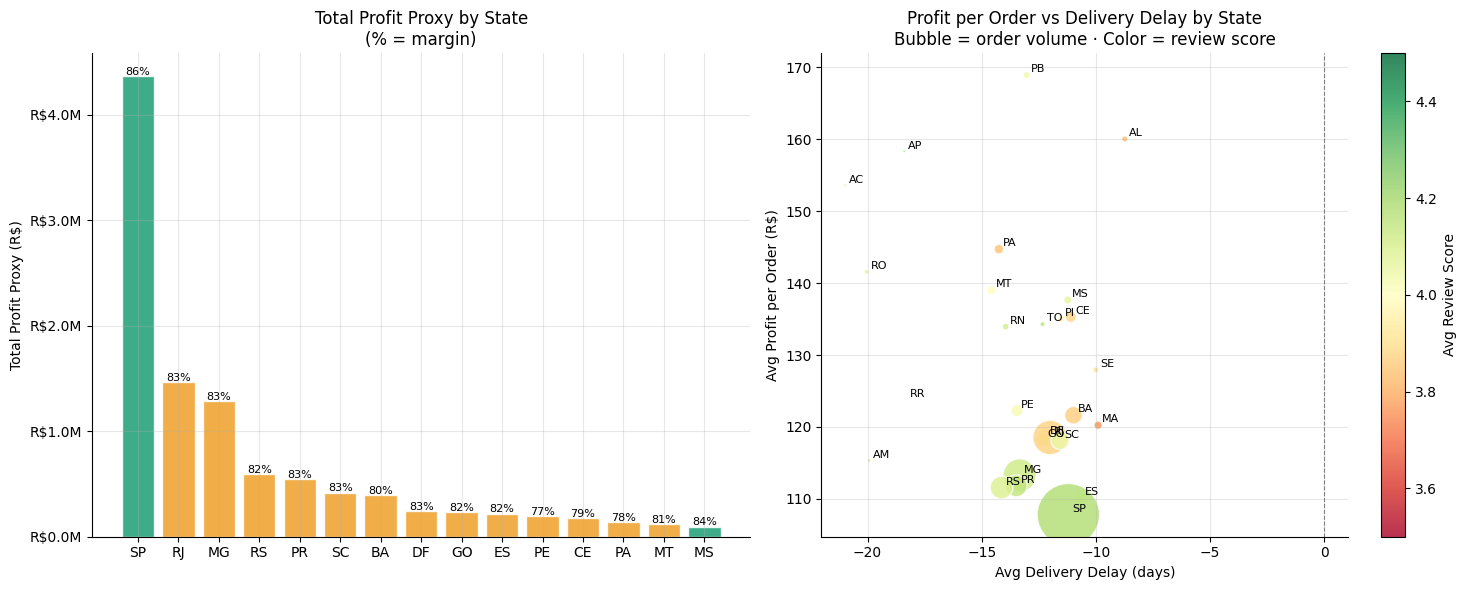

Chart saved!

Top 10 States by Profit per Order:
customer_state  profit_per_order  margin_pct  order_count  avg_delay
            PB            168.93       77.60          517     -13.04
            AL            160.05       80.60          397      -8.74
            AP            158.33       79.30           67     -18.40
            AC            153.58       77.10           80     -20.98
            PA            144.73       78.50          946     -14.25
            RO            141.56       75.30          243     -20.04
            MT            139.01       80.90          886     -14.57
            MS            137.65       83.60          701     -11.23
            CE            135.32       78.80         1279     -11.10
            PI            135.01       75.90          476     -11.53


In [7]:
state_profit = (
    delivered
    .groupby('customer_state')
    .agg(
        total_revenue   = ('price',         'sum'),
        total_freight   = ('freight_value', 'sum'),
        total_profit    = ('profit_proxy',  'sum'),
        order_count     = ('order_id',      'nunique'),
        avg_review      = ('review_score',  'mean'),
        avg_delay       = ('delivery_delay_days', 'mean')
    )
    .reset_index()
)
state_profit['margin_pct']      = (state_profit['total_profit'] / state_profit['total_revenue'] * 100).round(1)
state_profit['profit_per_order']= (state_profit['total_profit'] / state_profit['order_count']).round(2)
state_profit['freight_ratio']   = (state_profit['total_freight'] / state_profit['total_revenue'] * 100).round(1)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Total profit by state (top 15)
top15_states = state_profit.nlargest(15, 'total_profit')
bar_colors   = [GREEN if m > overall_margin_pct else AMBER for m in top15_states['margin_pct']]
bars = axes[0].bar(top15_states['customer_state'],
                   top15_states['total_profit'],
                   color=bar_colors, alpha=0.85, edgecolor='white')
for bar, m in zip(bars, top15_states['margin_pct']):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 10000,
                 f'{m:.0f}%', ha='center', fontsize=8)
axes[0].set_title('Total Profit Proxy by State\n(% = margin)', fontsize=12)
axes[0].set_ylabel('Total Profit Proxy (R$)')
axes[0].yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'R${x/1e6:.1f}M'))

# Profit per order vs avg delay scatter
scatter = axes[1].scatter(
    state_profit['avg_delay'],
    state_profit['profit_per_order'],
    s=state_profit['order_count'] / 20,
    c=state_profit['avg_review'],
    cmap='RdYlGn',
    alpha=0.8,
    edgecolors='white',
    vmin=3.5, vmax=4.5
)
plt.colorbar(scatter, ax=axes[1], label='Avg Review Score')
for _, row in state_profit.iterrows():
    axes[1].annotate(row['customer_state'],
                     (row['avg_delay'], row['profit_per_order']),
                     fontsize=8, xytext=(3, 2),
                     textcoords='offset points')
axes[1].axvline(0, color='gray', linewidth=0.8, linestyle='--')
axes[1].set_title('Profit per Order vs Delivery Delay by State\nBubble = order volume · Color = review score', fontsize=12)
axes[1].set_xlabel('Avg Delivery Delay (days)')
axes[1].set_ylabel('Avg Profit per Order (R$)')

plt.tight_layout()
plt.savefig(OUTPUTS_PATH + 'profit_by_state.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved!')
print('\nTop 10 States by Profit per Order:')
print(state_profit.nlargest(10, 'profit_per_order')[
    ['customer_state','profit_per_order','margin_pct','order_count','avg_delay']
].to_string(index=False))

## 8. Chart 5 — Seller Profit Analysis

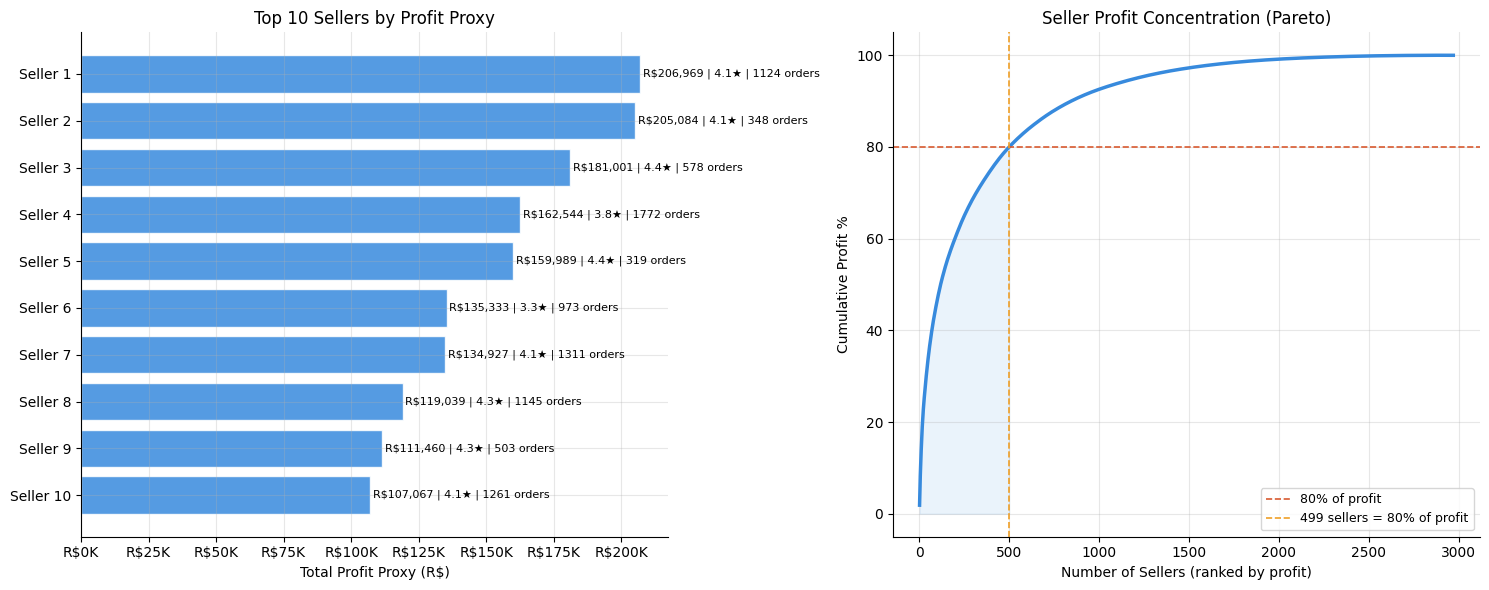

Chart saved!

Total sellers: 2,970
Top 10 sellers generate: 13.8% of total profit
Sellers needed for 80% of profit: 499


In [8]:
seller_profit = (
    delivered
    .groupby('seller_id')
    .agg(
        total_revenue   = ('price',          'sum'),
        total_freight   = ('freight_value',  'sum'),
        total_profit    = ('profit_proxy',   'sum'),
        order_count     = ('order_id',       'nunique'),
        avg_review      = ('review_score',   'mean'),
        avg_delay       = ('delivery_delay_days', 'mean'),
        seller_state    = ('seller_state',   'first')
    )
    .reset_index()
    .dropna(subset=['total_profit'])
)
seller_profit['margin_pct']       = (seller_profit['total_profit'] / seller_profit['total_revenue'] * 100).round(1)
seller_profit['profit_per_order'] = (seller_profit['total_profit'] / seller_profit['order_count']).round(2)
seller_profit_sorted = seller_profit.sort_values('total_profit', ascending=False).reset_index(drop=True)

# Revenue concentration: what % of profit comes from top N sellers
seller_profit_sorted['cum_profit_pct'] = (
    seller_profit_sorted['total_profit'].cumsum() /
    seller_profit_sorted['total_profit'].sum() * 100
)

top10_sellers = seller_profit_sorted.head(10)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Top 10 sellers by profit
axes[0].barh(
    [f'Seller {i+1}' for i in range(len(top10_sellers))],
    top10_sellers['total_profit'],
    color=BLUE, alpha=0.85, edgecolor='white'
)
for i, (_, row) in enumerate(top10_sellers.iterrows()):
    axes[0].text(row['total_profit'] + 1000, i,
                 f"R${row['total_profit']:,.0f} | {row['avg_review']:.1f}★ | {row['order_count']} orders",
                 va='center', fontsize=8)
axes[0].set_title('Top 10 Sellers by Profit Proxy', fontsize=12)
axes[0].set_xlabel('Total Profit Proxy (R$)')
axes[0].invert_yaxis()
axes[0].xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'R${x/1e3:.0f}K'))

# Pareto profit curve
axes[1].plot(range(1, len(seller_profit_sorted)+1),
             seller_profit_sorted['cum_profit_pct'],
             color=BLUE, linewidth=2.5)
axes[1].axhline(80, color=CORAL, linewidth=1.2, linestyle='--', label='80% of profit')
# Find how many sellers = 80%
n_sellers_80 = (seller_profit_sorted['cum_profit_pct'] <= 80).sum()
axes[1].axvline(n_sellers_80, color=AMBER, linewidth=1.2, linestyle='--',
                label=f'{n_sellers_80} sellers = 80% of profit')
axes[1].fill_between(range(1, n_sellers_80+1),
                     seller_profit_sorted['cum_profit_pct'].iloc[:n_sellers_80],
                     alpha=0.1, color=BLUE)
axes[1].set_title('Seller Profit Concentration (Pareto)', fontsize=12)
axes[1].set_xlabel('Number of Sellers (ranked by profit)')
axes[1].set_ylabel('Cumulative Profit %')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig(OUTPUTS_PATH + 'seller_profit_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved!')
top10_profit_pct = top10_sellers['total_profit'].sum() / seller_profit['total_profit'].sum() * 100
print(f'\nTotal sellers: {len(seller_profit):,}')
print(f'Top 10 sellers generate: {top10_profit_pct:.1f}% of total profit')
print(f'Sellers needed for 80% of profit: {n_sellers_80}')

## 9. Chart 6 — Monthly Profit Trend

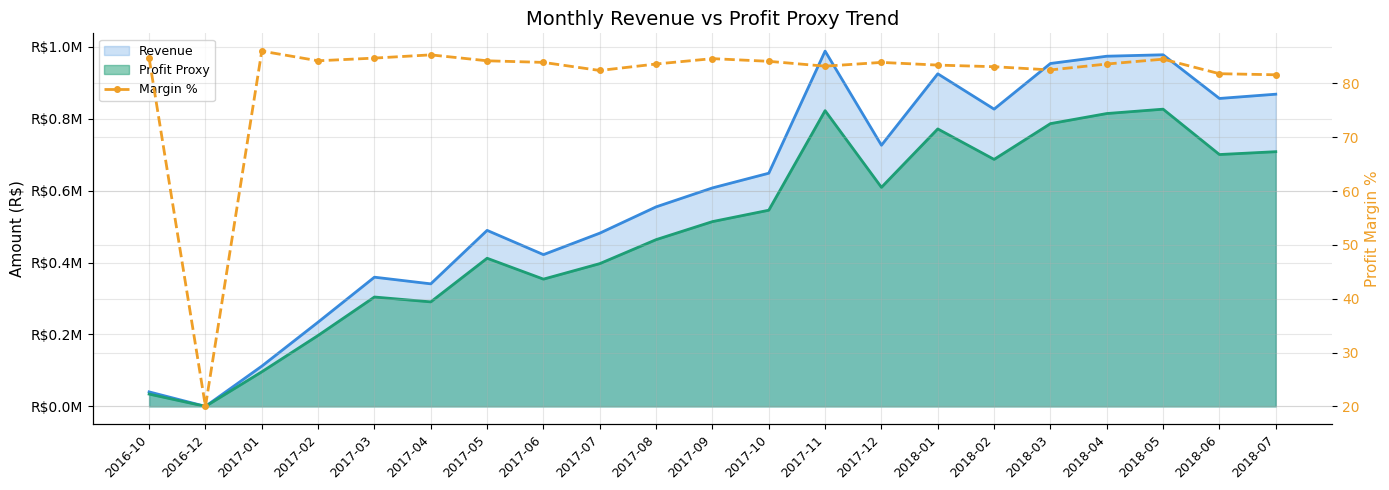

Chart saved!

Avg monthly margin: 80.7%
Best margin month : 2017-01 (86.0%)
Worst margin month: 2016-12 (20.0%)


In [9]:
monthly_profit = (
    delivered
    .groupby('order_month_str')
    .agg(
        total_revenue  = ('price',         'sum'),
        total_freight  = ('freight_value', 'sum'),
        total_profit   = ('profit_proxy',  'sum'),
        order_count    = ('order_id',      'nunique')
    )
    .reset_index()
    .sort_values('order_month_str')
    .iloc[1:-1]  # remove incomplete first/last months
    .reset_index(drop=True)
)
monthly_profit['margin_pct'] = (monthly_profit['total_profit'] / monthly_profit['total_revenue'] * 100).round(1)

fig, ax1 = plt.subplots(figsize=(14, 5))

# Revenue and profit stacked
ax1.fill_between(monthly_profit['order_month_str'],
                 monthly_profit['total_revenue'],
                 alpha=0.25, color=BLUE, label='Revenue')
ax1.fill_between(monthly_profit['order_month_str'],
                 monthly_profit['total_profit'],
                 alpha=0.5, color=GREEN, label='Profit Proxy')
ax1.plot(monthly_profit['order_month_str'],
         monthly_profit['total_revenue'],
         color=BLUE, linewidth=2)
ax1.plot(monthly_profit['order_month_str'],
         monthly_profit['total_profit'],
         color=GREEN, linewidth=2)
ax1.set_ylabel('Amount (R$)', fontsize=11)
ax1.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'R${x/1e6:.1f}M'))
plt.xticks(rotation=45, ha='right', fontsize=9)

# Margin % on secondary axis
ax2 = ax1.twinx()
ax2.plot(monthly_profit['order_month_str'],
         monthly_profit['margin_pct'],
         color=AMBER, linewidth=2, linestyle='--',
         marker='o', markersize=4, label='Margin %')
ax2.set_ylabel('Profit Margin %', color=AMBER, fontsize=11)
ax2.tick_params(axis='y', labelcolor=AMBER)

ax1.set_title('Monthly Revenue vs Profit Proxy Trend', fontsize=14)
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=9)

plt.tight_layout()
plt.savefig(OUTPUTS_PATH + 'monthly_profit_trend.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved!')
print(f"\nAvg monthly margin: {monthly_profit['margin_pct'].mean():.1f}%")
print(f"Best margin month : {monthly_profit.loc[monthly_profit['margin_pct'].idxmax(), 'order_month_str']} ({monthly_profit['margin_pct'].max():.1f}%)")
print(f"Worst margin month: {monthly_profit.loc[monthly_profit['margin_pct'].idxmin(), 'order_month_str']} ({monthly_profit['margin_pct'].min():.1f}%)")

## 10. Chart 7 — Price vs Freight Scatter by Category

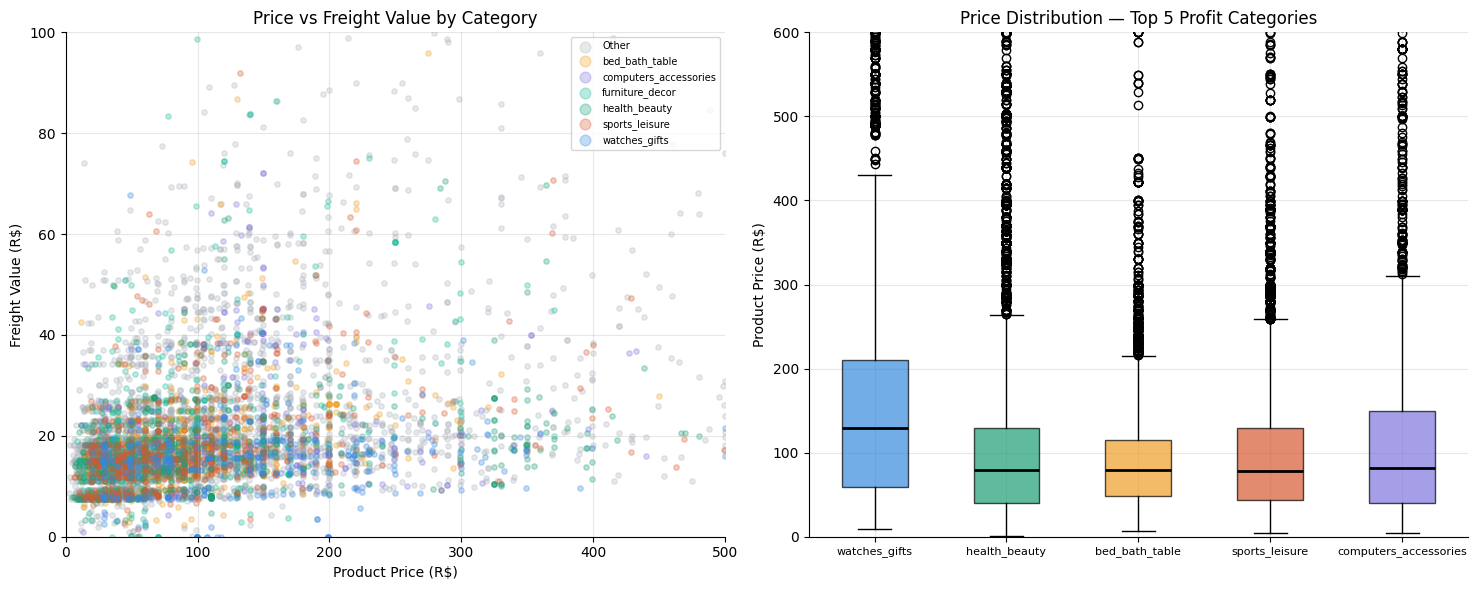

Chart saved!


In [10]:
# Sample for performance
sample = delivered.dropna(subset=['product_category_name_english']).sample(
    n=min(8000, len(delivered)), random_state=42
)

# Get top 6 categories for colour coding
top6_cats = category_profit.nlargest(6, 'total_profit')['product_category_name_english'].tolist()
sample['cat_label'] = sample['product_category_name_english'].apply(
    lambda x: x if x in top6_cats else 'Other'
)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Scatter: price vs freight
cat_colors = {cat: c for cat, c in zip(
    top6_cats + ['Other'],
    [BLUE, GREEN, AMBER, CORAL, PURPLE, '#1abc9c', '#adb5bd']
)}
for cat, group in sample.groupby('cat_label'):
    axes[0].scatter(group['price'], group['freight_value'],
                    alpha=0.3, s=15,
                    color=cat_colors.get(cat, '#adb5bd'),
                    label=cat)
axes[0].set_title('Price vs Freight Value by Category', fontsize=12)
axes[0].set_xlabel('Product Price (R$)')
axes[0].set_ylabel('Freight Value (R$)')
axes[0].set_xlim(0, 500)
axes[0].set_ylim(0, 100)
axes[0].legend(fontsize=7, markerscale=2)

# Price distribution by top categories
top5_cats  = category_profit.nlargest(5, 'total_profit')['product_category_name_english'].tolist()
box_data   = [delivered[delivered['product_category_name_english'] == cat]['price'].dropna()
              for cat in top5_cats]
bp = axes[1].boxplot(box_data, patch_artist=True,
                     boxprops=dict(alpha=0.7),
                     medianprops=dict(color='black', linewidth=2))
colors_box = [BLUE, GREEN, AMBER, CORAL, PURPLE]
for patch, color in zip(bp['boxes'], colors_box):
    patch.set_facecolor(color)
axes[1].set_xticklabels(
    [c.replace(' ', '\n') for c in top5_cats],
    fontsize=8
)
axes[1].set_title('Price Distribution — Top 5 Profit Categories', fontsize=12)
axes[1].set_ylabel('Product Price (R$)')
axes[1].set_ylim(0, 600)

plt.tight_layout()
plt.savefig(OUTPUTS_PATH + 'price_vs_freight_scatter.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved!')

## 11. Chart 8 — Negative Margin Orders Analysis

AttributeError: 'float' object has no attribute 'abs'

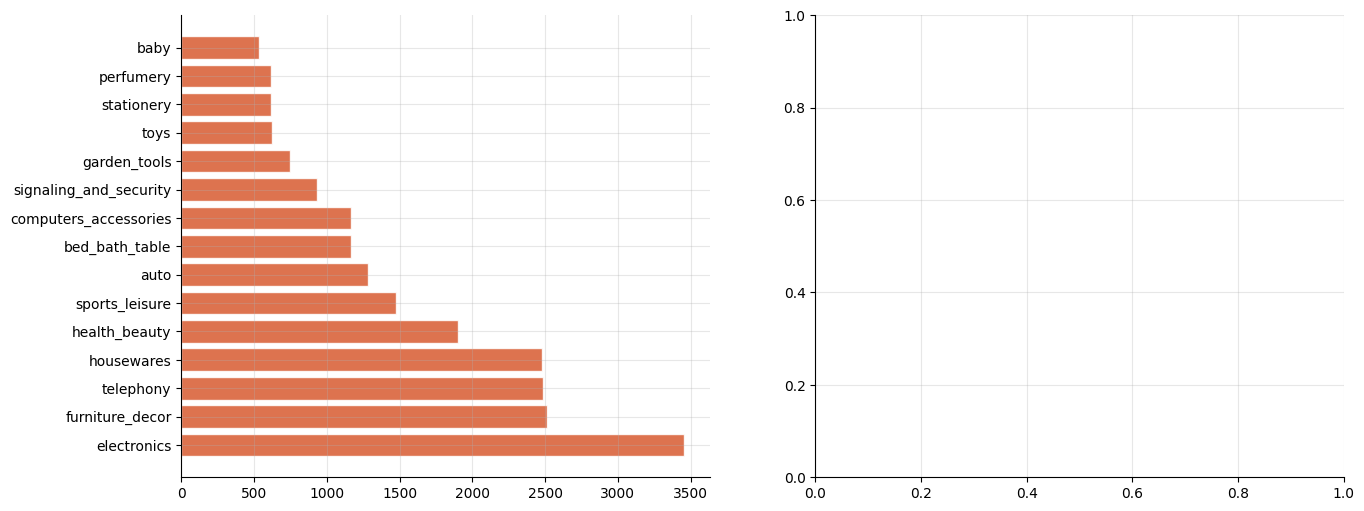

In [11]:
# Orders where freight > price (negative margin)
negative = delivered[delivered['profit_proxy'] < 0].copy()

neg_by_cat = (
    negative
    .dropna(subset=['product_category_name_english'])
    .groupby('product_category_name_english')
    .agg(
        count          = ('order_id', 'count'),
        total_loss     = ('profit_proxy', 'sum'),
        avg_loss       = ('profit_proxy', 'mean')
    )
    .reset_index()
    .sort_values('total_loss')
    .head(15)
)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Categories with most total loss
axes[0].barh(neg_by_cat['product_category_name_english'],
             neg_by_cat['total_loss'].abs(),
             color=CORAL, alpha=0.85, edgecolor='white')
for i, (_, row) in enumerate(neg_by_cat.iterrows()):
    axes[0].text(row['total_loss'].abs() + 100, i,
                 f"{row['count']} orders",
                 va='center', fontsize=8)
axes[0].set_title('Categories with Highest Total Loss\n(freight > price orders)', fontsize=12)
axes[0].set_xlabel('Total Loss (R$, absolute)')
axes[0].invert_yaxis()

# Loss distribution
axes[1].hist(negative['profit_proxy'].clip(-200, 0), bins=50,
             color=CORAL, alpha=0.85, edgecolor='white')
axes[1].axvline(negative['profit_proxy'].mean(), color='black',
                linewidth=2, linestyle='--',
                label=f"Avg loss: R${negative['profit_proxy'].mean():.2f}")
axes[1].set_title('Distribution of Negative Margin Orders', fontsize=12)
axes[1].set_xlabel('Profit Proxy (R$) — negative means loss')
axes[1].set_ylabel('Number of Orders')
axes[1].legend(fontsize=10)

plt.suptitle(f'Negative Margin Analysis — {len(negative):,} orders ({len(negative)/len(delivered)*100:.1f}% of delivered)', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(OUTPUTS_PATH + 'negative_margin_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved!')
print(f'\nTotal loss from negative margin orders: R$ {negative["profit_proxy"].sum():,.2f}')
print(f'Avg loss per negative order           : R$ {negative["profit_proxy"].mean():,.2f}')

## 12. Profit Summary Table — All Categories

In [12]:
# Complete profit table — export to CSV
profit_table = category_profit[
    ['product_category_name_english','total_revenue','total_freight',
     'total_profit','margin_pct','freight_ratio','order_count',
     'profit_per_order','avg_review']
].sort_values('total_profit', ascending=False).reset_index(drop=True)

# Save to outputs
profit_table.to_csv(OUTPUTS_PATH + 'category_profit_summary.csv', index=False)

print('Full Category Profit Table (Top 20):')
print(profit_table.head(20).to_string(index=False))
print(f'\nFull table saved to outputs/category_profit_summary.csv')

Full Category Profit Table (Top 20):
product_category_name_english  total_revenue  total_freight  total_profit  margin_pct  freight_ratio  order_count  profit_per_order  avg_review
                watches_gifts     1166176.98       98156.14    1068020.84       91.60           8.40         5495            194.36        4.07
                health_beauty     1233131.72      178957.81    1054173.91       85.50          14.50         8647            121.91        4.19
               bed_bath_table     1023434.76      201774.50     821660.26       80.30          19.70         9272             88.62        3.92
               sports_leisure      954852.55      163404.36     791448.19       82.90          17.10         7530            105.11        4.17
        computers_accessories      888724.61      143999.16     744725.45       83.80          16.20         6530            114.05        3.99
              furniture_decor      711927.69      168402.23     543525.46       76.30          23.7

## 13. Final Profit Intelligence Summary

In [13]:
best_cat   = category_profit.loc[category_profit['total_profit'].idxmax(), 'product_category_name_english']
worst_cat  = category_profit.loc[category_profit['freight_ratio'].idxmax(), 'product_category_name_english']
best_state = state_profit.loc[state_profit['profit_per_order'].idxmax(), 'customer_state']

print('=' * 60)
print('         PROFIT ANALYSIS — KEY FINDINGS')
print('=' * 60)
print(f"""
OVERALL
  Total profit proxy          : R$ {total_profit:>12,.0f}
  Overall margin              : {overall_margin_pct:>13.1f}%
  Freight as % of revenue     : {avg_freight_ratio:>13.1f}%
  Negative margin orders      : {negative_margin:>12,} ({negative_margin_pct:.1f}%)

CATEGORY INSIGHTS
  Highest profit category     : {best_cat}
  Highest freight ratio cat   : {worst_cat}
  Categories with >30% freight: {(category_profit['freight_ratio'] > 30).sum()}

SELLER INSIGHTS
  Total active sellers        : {len(seller_profit):>12,}
  Top 10 seller profit share  : {top10_profit_pct:>12.1f}%
  Sellers needed for 80%      : {n_sellers_80:>12,}

STATE INSIGHTS
  Highest profit per order    : {best_state}
  SP revenue dominance        : {state_profit[state_profit['customer_state']=='SP']['total_revenue'].values[0]/state_profit['total_revenue'].sum()*100:.1f}%

RECOMMENDATIONS
  1. Prioritise Health & Beauty, Watches, Computers (high margin)
  2. Renegotiate freight for bulky categories (>30% freight ratio)
  3. Protect top 10 sellers — they drive majority of profit
  4. Investigate negative margin orders — reduce or reprice

CHARTS SAVED
  profit_by_category.png
  category_profit_bubble.png
  freight_deep_dive.png
  profit_by_state.png
  seller_profit_analysis.png
  monthly_profit_trend.png
  price_vs_freight_scatter.png
  negative_margin_analysis.png
  category_profit_summary.csv
""")
print('=' * 60)
print('Next → Notebook 04: Customer Segmentation (RFM + CLV)')
print('=' * 60)

         PROFIT ANALYSIS — KEY FINDINGS

OVERALL
  Total profit proxy          : R$   11,023,222
  Overall margin              :          83.4%
  Freight as % of revenue     :          16.6%
  Negative margin orders      :        4,008 (3.6%)

CATEGORY INSIGHTS
  Highest profit category     : watches_gifts
  Highest freight ratio cat   : home_comfort_2
  Categories with >30% freight: 7

SELLER INSIGHTS
  Total active sellers        :        2,970
  Top 10 seller profit share  :         13.8%
  Sellers needed for 80%      :          499

STATE INSIGHTS
  Highest profit per order    : PB
  SP revenue dominance        : 38.3%

RECOMMENDATIONS
  1. Prioritise Health & Beauty, Watches, Computers (high margin)
  2. Renegotiate freight for bulky categories (>30% freight ratio)
  3. Protect top 10 sellers — they drive majority of profit
  4. Investigate negative margin orders — reduce or reprice

CHARTS SAVED
  profit_by_category.png
  category_profit_bubble.png
  freight_deep_dive.png
  profi

---
## Next Step → Notebook 04: Customer Segmentation

```python
master = pd.read_csv('../data/master_olist.csv')
```